# https://github.com/EraX-AI/viF5TTS?tab=readme-ov-file

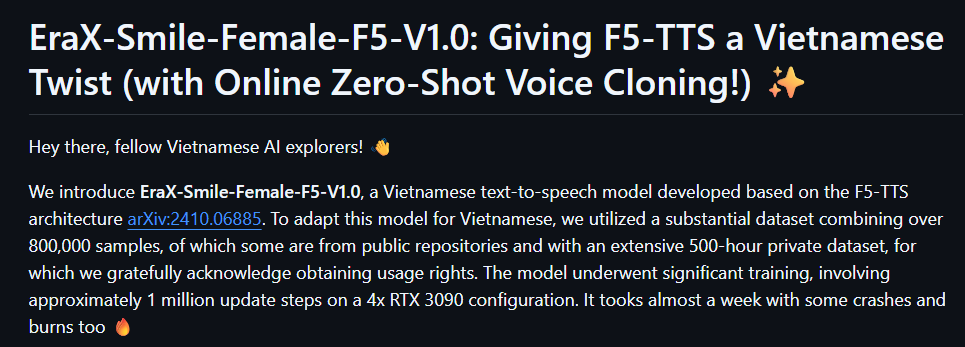

In [1]:
!git clone https://github.com/EraX-AI/viF5TTS.git

fatal: destination path 'viF5TTS' already exists and is not an empty directory.


In [2]:
!pip install vinorm cached_path safetensors hydra-core -q f5_tts

In [1]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"] =  "0" # Tell it which GPU to use (or ignore if you're CPU-bound and patient!)

from vinorm import TTSnorm # Gotta normalize that Vietnamese text first
from viF5TTS.src.model_pruning.f5tts_wrapper import F5TTSWrapper # Our handy wrapper class

d:\Ky 4\vietnamese-speech-chatbox\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from safetensors.torch import load_file
eraX_ckpt_path = "model_45000.safetensors"

In [3]:
# --- Config ---
# Path to the model checkpoint you downloaded from *this* repo
# MAKE SURE this path points to the actual .pth or .ckpt file!
# eraX_ckpt_path = "path/to/your/downloaded/EraX-Smile-Female-F5-V1.0/model.pth" # <-- CHANGE THIS!

# Path to the voice you want to clone
ref_audio_path = "update_213000_ref.wav" # <-- CHANGE THIS!

# Path to the vocab file from this repo
vocab_file = "vocab.txt" # <-- CHANGE THIS!

# Where to save the generated sound
output_dir = ""

# --- Texts ---
# Text matching the reference audio (helps the model learn the voice). Please make sure it match with the referrence audio!
ref_text = "Thậm chí không ăn thì cũng có cảm giác rất là cứng bụng, chủ yếu là cái phần rốn...trở lên. Em có cảm giác khó thở, và ngủ cũng không ngon, thường bị ợ hơi rất là nhiều"

# The text you want the cloned voice to speak
text_to_generate = "Trong khi đó, tại một chung cư trên địa bàn P.Vĩnh Tuy (Q.Hoàng Mai), nhiều người sống trên tầng cao giật mình khi thấy rung lắc mạnh nên đã chạy xuống sảnh tầng 1. Cư dân tại đây cho biết, họ chưa bao giờ cảm thấy ảnh hưởng của động đất mạnh như hôm nay."

# --- Let's Go! ---
print("Initializing the TTS engine... (Might take a sec)")
tts = F5TTSWrapper(
    vocoder_name="vocos", # Using Vocos vocoder
    ckpt_path=eraX_ckpt_path,
    vocab_file=vocab_file,
    use_ema=False, # ALWAYS False as we converted from .pt to safetensors and EMA (where there is or not) was in there
)

# Normalize the reference text (makes it easier for the model)
ref_text_norm = TTSnorm(ref_text)

# Prepare the output folder
os.makedirs(output_dir, exist_ok=True)

print("Processing the reference voice...")
# Feed the model the reference voice ONCE
# Provide ref_text for better quality, or set ref_text="" to use Whisper for auto-transcription (if installed)
tts.preprocess_reference(
    ref_audio_path=ref_audio_path,
    ref_text=ref_text_norm,
    clip_short=True # Keeps reference audio to a manageable length (~12s)
)
print(f"Reference audio duration used: {tts.get_current_audio_length():.2f} seconds")

# --- Generate New Speech ---
print("Generating new speech with the cloned voice...")

# Normalize the text we want to speak
text_norm = TTSnorm(text_to_generate)

# You can generate multiple sentences easily
# Just add more normalized strings to this list
sentences = [text_norm]

for i, sentence in enumerate(sentences):
    output_path = os.path.join(output_dir, f"generated_speech_{i+1}.wav")

    # THE ACTUAL GENERATION HAPPENS HERE!
    tts.generate(
        text=sentence,
        output_path=output_path,
        nfe_step=32,               # Denoising steps. More = slower but potentially better? (Default: 32)
        cfg_strength=2.0,          # How strongly to stick to the reference voice style? (Default: 2.0)
        speed=1.0,                 # Make it talk faster or slower (Default: 1.0)
        cross_fade_duration=0.15,  # Smooths transitions if text is split into chunks (Default: 0.15)
    )
    print(f"Boom! Audio saved to: {output_path}")

print("\nAll done! Check your output folder.")


Initializing the TTS engine... (Might take a sec)


Device set to use cuda


Download Vocos from huggingface charactr/vocos-mel-24khz


OSError: [WinError 193] %1 is not a valid Win32 application

In [ ]:
# --- Config ---
# Path to the model checkpoint you downloaded from *this* repo
# MAKE SURE this path points to the actual .pth or .ckpt file!
# eraX_ckpt_path = "path/to/your/downloaded/EraX-Smile-Female-F5-V1.0/model.pth" # <-- CHANGE THIS!

# Path to the voice you want to clone
ref_audio_path = "/kaggle/input/holahola/notebooks/update_213000_ref.wav" # <-- CHANGE THIS!

# Path to the vocab file from this repo
vocab_file = "/kaggle/input/holahola/notebooks/vocab.txt" # <-- CHANGE THIS!

# Where to save the generated sound
output_dir = "/kaggle/working/output_folder"

# --- Texts ---
# Text matching the reference audio (helps the model learn the voice). Please make sure it match with the referrence audio!
ref_text = "Thậm chí không ăn thì cũng có cảm giác rất là cứng bụng, chủ yếu là cái phần rốn...trở lên. Em có cảm giác khó thở, và ngủ cũng không ngon, thường bị ợ hơi rất là nhiều"

# The text you want the cloned voice to speak
text_to_generate = """
Chào mừng các bạn đến với môn “Khám phá dữ liệu với AI và Khai phá tri thức” – nghe tên hơi dài dòng nhưng nội dung thì rất thú vị nha!
Trong môn này, tụi mình sẽ học cách làm việc với dữ liệu – kiểu như mấy bảng số liệu, văn bản, thông tin trên web,... Sau đó dùng AI (kiểu như ChatGPT) để đọc, hiểu và rút ra những điều hay ho từ đống dữ liệu đó.
Mình sẽ học những gì?
Biết cách tìm và thu thập dữ liệu đúng cách. Làm quen với việc xử lý và làm sạch dữ liệu để dễ phân tích hơn.
Dùng AI để phân tích văn bản, kiểu như cho máy hiểu nội dung tài liệu.
Làm quen với khai phá tri thức – tức là tìm ra thông tin ẩn trong dữ liệu mà người thường khó thấy được.
Học xong để làm gì?
Bạn sẽ có được nền tảng vững về làm việc với dữ liệu và biết cách tận dụng AI để hỗ trợ học tập hoặc làm việc sau này. Nói đơn giản là, biết cách “nói chuyện” với dữ liệu và nhờ AI giúp mình giải quyết vấn đề.
"""

# --- Let's Go! ---
print("Initializing the TTS engine... (Might take a sec)")
tts = F5TTSWrapper(
    vocoder_name="vocos", # Using Vocos vocoder
    ckpt_path=eraX_ckpt_path,
    vocab_file=vocab_file,
    use_ema=False, # ALWAYS False as we converted from .pt to safetensors and EMA (where there is or not) was in there
)

# Normalize the reference text (makes it easier for the model)
ref_text_norm = TTSnorm(ref_text)

# Prepare the output folder
os.makedirs(output_dir, exist_ok=True)

print("Processing the reference voice...")
# Feed the model the reference voice ONCE
# Provide ref_text for better quality, or set ref_text="" to use Whisper for auto-transcription (if installed)
tts.preprocess_reference(
    ref_audio_path=ref_audio_path,
    ref_text=ref_text_norm,
    clip_short=True # Keeps reference audio to a manageable length (~12s)
)
print(f"Reference audio duration used: {tts.get_current_audio_length():.2f} seconds")

# --- Generate New Speech ---
print("Generating new speech with the cloned voice...")

# Normalize the text we want to speak
text_norm = TTSnorm(text_to_generate)

# You can generate multiple sentences easily
# Just add more normalized strings to this list
sentences = [text_norm]

for i, sentence in enumerate(sentences):
    output_path = os.path.join(output_dir, f"generated_speech_{i+1}.wav")

    # THE ACTUAL GENERATION HAPPENS HERE!
    tts.generate(
        text=sentence,
        output_path=output_path,
        nfe_step=32,               # Denoising steps. More = slower but potentially better? (Default: 32)
        cfg_strength=2.0,          # How strongly to stick to the reference voice style? (Default: 2.0)
        speed=1.0,                 # Make it talk faster or slower (Default: 1.0)
        cross_fade_duration=0.15,  # Smooths transitions if text is split into chunks (Default: 0.15)
    )
    print(f"Boom! Audio saved to: {output_path}")

import zipfile

file_to_zip = os.path.join(output_dir, "generated_speech_1.wav")
zip_file = os.path.join(output_dir, "generated_speech_1.zip")

if os.path.isfile(file_to_zip):
    with zipfile.ZipFile(zip_file, 'w') as zipf:
        zipf.write(file_to_zip, arcname="generated_speech_1.wav")
    print(f"Zipped successfully: {zip_file}")
else:
    print(f"File not found: {file_to_zip}")


Initializing the TTS engine... (Might take a sec)


Device set to use cuda


Download Vocos from huggingface charactr/vocos-mel-24khz
Processing the reference voice...
Converting audio...
Using custom reference text...

Reference text: thậm chí không ăn thì cũng có cảm giác rất là cứng bụng , chủ yếu là cái phần rốn trở lên . em có cảm giác khó thở , và ngủ cũng không ngon , thường bị ợ hơi rất là nhiều. 
Reference audio duration used: 10.70 seconds
Generating new speech with the cloned voice...
Text batch 0: chào mừng các bạn đến với môn khám phá dữ liệu với ai và khai phá tri thức nghe tên hơi dài dòng nhưng nội dung thì rất thú vị nha .. trong môn này ,
Text batch 1: tụi mình sẽ học cách làm việc với dữ liệu kiểu như mấy bảng số liệu , văn bản , thông tin trên web , sau đó dùng ai kiểu như chatgpt để đọc ,
Text batch 2: hiểu và rút ra những điều hay ho từ đống dữ liệu đó .. mình sẽ học những gì .. biết cách tìm và thu thập dữ liệu đúng cách .
Text batch 3: làm quen với việc xử lý và làm sạch dữ liệu để dễ phân tích hơn .. dùng ai để phân tích văn bản , kiểu 